In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/df_analysis.csv', sep=';', dtype={'CODE_INSEE': str})

display(df)

,CITY,CODE_INSEE,POPULATION_TOTAL,RATE_SEX_WOMEN,RATE_SEX_MEN,RATE_SPC_FARMERS,RATE_SPC_BUSINESS,RATE_SPC_INACTIVES,RATE_SPC_EXECUTIVES,RATE_SPC_EMPLOYEES,...,Votants,Blancs,Nuls,Exprimés,pct_abstention,pct_blancs,pct_nuls,pct_gauche,pct_centre,pct_droite
0,Beauregard,01030,869.566928,53.935253,46.064747,0.538078,5.726432,6.894794,13.796098,15.949578,...,433.0,2.0,4.0,427.0,23.77,0.46,0.92,26.93,26.46,46.60
1,Belley,01034,7806.621047,51.471871,48.528129,0.191526,2.936936,15.260494,4.724304,15.391478,...,4341.0,72.0,28.0,4241.0,26.89,1.66,0.65,31.86,27.89,40.25
2,Bourg-en-Bresse,01053,35214.492761,52.884150,47.115850,0.030002,2.094780,20.706236,7.183482,14.570836,...,16316.0,252.0,72.0,15992.0,29.54,1.54,0.44,37.24,30.30,32.45
3,Brens,01061,2918.369191,52.085709,47.914291,0.342947,5.482304,12.063919,9.281433,14.541792,...,777.0,13.0,5.0,759.0,18.30,1.67,0.64,26.09,28.06,45.85
4,Cerdon,01068,1418.434561,51.925152,48.074848,0.703176,4.553252,11.116052,5.226455,13.601789,...,431.0,7.0,3.0,421.0,23.04,1.62,0.70,21.38,20.43,58.19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29763,Villers-en-Arthies,95676,379.952568,55.321808,44.678192,0.000000,5.322118,10.329886,9.247334,20.828239,...,340.0,2.0,0.0,338.0,12.82,0.59,0.00,26.63,27.51,45.86
29764,Villiers-Adam,95678,678.400000,47.058824,52.941176,0.000000,8.088235,13.235294,16.911765,11.029412,...,531.0,9.0,5.0,517.0,11.94,1.69,0.94,25.73,31.33,42.94
29765,Villiers-le-Bel,95680,21596.176049,51.602206,48.397794,0.000000,2.962626,27.844007,4.086016,20.954176,...,8388.0,106.0,76.0,8206.0,32.36,1.26,0.91,59.10,19.34,21.56
29766,Villiers-le-Sec,95682,763.684826,51.227657,48.772343,0.576243,3.290803,13.903526,5.070045,21.503831,...,96.0,0.0,1.0,95.0,12.73,0.00,1.04,31.58,29.47,38.95


In [76]:
df.dtypes

CITY                             str
CODE_INSEE                       str
POPULATION_TOTAL             float64
RATE_SEX_WOMEN               float64
RATE_SEX_MEN                 float64
RATE_SPC_FARMERS             float64
RATE_SPC_BUSINESS            float64
RATE_SPC_INACTIVES           float64
RATE_SPC_EXECUTIVES          float64
RATE_SPC_EMPLOYEES           float64
RATE_SPC_WORKERS             float64
RATE_SPC_INTERMEDIATES       float64
RATE_SPC_RETIRED             float64
RATE_FAMILY_CHILDREN         float64
RATE_FAMILY_CHILDLESS        float64
RATE_FAMILY_SINGLE_PARENT    float64
RATE_ONE_WOMAN               float64
RATE_ONE_MAN                 float64
RATE_FAMILY                  float64
RATE_HOUSESHARE              float64
RATE_ONE_PERSON              float64
RATE_AGE_80+                 float64
RATE_AGE_15_24               float64
RATE_AGE_25_39               float64
RATE_AGE_40_54               float64
RATE_AGE_55_64               float64
RATE_AGE_65_79               float64
R

In [77]:
df.columns

Index(['CITY', 'CODE_INSEE', 'POPULATION_TOTAL', 'RATE_SEX_WOMEN',
       'RATE_SEX_MEN', 'RATE_SPC_FARMERS', 'RATE_SPC_BUSINESS',
       'RATE_SPC_INACTIVES', 'RATE_SPC_EXECUTIVES', 'RATE_SPC_EMPLOYEES',
       'RATE_SPC_WORKERS', 'RATE_SPC_INTERMEDIATES', 'RATE_SPC_RETIRED',
       'RATE_FAMILY_CHILDREN', 'RATE_FAMILY_CHILDLESS',
       'RATE_FAMILY_SINGLE_PARENT', 'RATE_ONE_WOMAN', 'RATE_ONE_MAN',
       'RATE_FAMILY', 'RATE_HOUSESHARE', 'RATE_ONE_PERSON', 'RATE_AGE_80+',
       'RATE_AGE_15_24', 'RATE_AGE_25_39', 'RATE_AGE_40_54', 'RATE_AGE_55_64',
       'RATE_AGE_65_79', 'RATE_SINGLE', 'RATE_DIVORCED', 'RATE_LIVEIN_PARTNER',
       'RATE_MARRIED', 'RATE_CIVIL_PARTNER', 'RATE_WIDOWED', 'Inscrits',
       'Abstentions', 'Votants', 'Blancs', 'Nuls', 'Exprimés',
       'pct_abstention', 'pct_blancs', 'pct_nuls', 'pct_gauche', 'pct_centre',
       'pct_droite'],
      dtype='str')

In [78]:
df['majorite'] = df[['pct_gauche', 'pct_centre', 'pct_droite']].idxmax(axis=1)
metier = ['RATE_SPC_EMPLOYEES', 'RATE_SPC_WORKERS', 'RATE_SPC_INTERMEDIATES', 'RATE_SPC_RETIRED', 'RATE_SPC_EXECUTIVES', 'RATE_SPC_INACTIVES', 'RATE_SPC_BUSINESS', 'RATE_SPC_FARMERS']
age = ['RATE_AGE_15_24', 'RATE_AGE_25_39', 'RATE_AGE_40_54', 'RATE_AGE_55_64', 'RATE_AGE_65_79', 'RATE_AGE_80+']
status = ['RATE_SINGLE', 'RATE_DIVORCED', 'RATE_LIVEIN_PARTNER', 'RATE_MARRIED', 'RATE_CIVIL_PARTNER', 'RATE_WIDOWED']
menage = ['RATE_FAMILY_CHILDREN', 'RATE_FAMILY_CHILDLESS','RATE_FAMILY_SINGLE_PARENT', 'RATE_ONE_WOMAN', 'RATE_ONE_MAN', 'RATE_FAMILY', 'RATE_HOUSESHARE', 'RATE_ONE_PERSON']

In [79]:
df['sum_metier'] = df[metier].sum(axis=1)
df[df['sum_metier'] > 104][['CITY', 'POPULATION_TOTAL', 'sum_metier']]
df = df[df['sum_metier'] <= 104]

In [80]:
df['sum_age'] = df[age].sum(axis=1)
df[df['sum_age'] > 104][['CITY', 'POPULATION_TOTAL', 'sum_age']]
df = df[df['sum_age'] <= 104]

In [81]:
df['sum_status'] = df[status].sum(axis=1)
df[df['sum_status'] > 104][['CITY', 'POPULATION_TOTAL', 'sum_status']]
df = df[df['sum_status'] <= 104]

In [82]:
menage_top = ['RATE_FAMILY', 'RATE_HOUSESHARE', 'RATE_ONE_PERSON']
df['sum_menage_top'] = df[menage_top].sum(axis=1)
df[df['sum_menage_top'] > 104][['CITY', 'POPULATION_TOTAL', 'sum_menage_top']]
df = df[df['sum_menage_top'] <= 104]

In [83]:
menage_no_top = ['RATE_FAMILY_CHILDREN', 'RATE_FAMILY_CHILDLESS','RATE_FAMILY_SINGLE_PARENT', 'RATE_ONE_WOMAN', 'RATE_ONE_MAN']
df['sum_menage_no_top'] = df[menage_no_top].sum(axis=1)
df[df['sum_menage_no_top'] > 100.1][['CITY', 'POPULATION_TOTAL', 'sum_menage_no_top']]

,CITY,POPULATION_TOTAL,sum_menage_no_top


In [84]:
df = df[df['Inscrits'] > 100]
df = df[df['POPULATION_TOTAL'] > 100]

display(df)

,CITY,CODE_INSEE,POPULATION_TOTAL,RATE_SEX_WOMEN,RATE_SEX_MEN,RATE_SPC_FARMERS,RATE_SPC_BUSINESS,RATE_SPC_INACTIVES,RATE_SPC_EXECUTIVES,RATE_SPC_EMPLOYEES,...,pct_nuls,pct_gauche,pct_centre,pct_droite,majorite,sum_metier,sum_age,sum_status,sum_menage_top,sum_menage_no_top
0,Beauregard,01030,869.566928,53.935253,46.064747,0.538078,5.726432,6.894794,13.796098,15.949578,...,0.92,26.93,26.46,46.60,pct_droite,100.0,100.0,100.0,100.0,91.244724
1,Belley,01034,7806.621047,51.471871,48.528129,0.191526,2.936936,15.260494,4.724304,15.391478,...,0.65,31.86,27.89,40.25,pct_droite,100.0,100.0,100.0,100.0,95.121951
2,Bourg-en-Bresse,01053,35214.492761,52.884150,47.115850,0.030002,2.094780,20.706236,7.183482,14.570836,...,0.44,37.24,30.30,32.45,pct_gauche,100.0,100.0,100.0,100.0,95.751412
3,Brens,01061,2918.369191,52.085709,47.914291,0.342947,5.482304,12.063919,9.281433,14.541792,...,0.64,26.09,28.06,45.85,pct_droite,100.0,100.0,100.0,100.0,100.000000
4,Cerdon,01068,1418.434561,51.925152,48.074848,0.703176,4.553252,11.116052,5.226455,13.601789,...,0.70,21.38,20.43,58.19,pct_droite,100.0,100.0,100.0,100.0,100.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29763,Villers-en-Arthies,95676,379.952568,55.321808,44.678192,0.000000,5.322118,10.329886,9.247334,20.828239,...,0.00,26.63,27.51,45.86,pct_droite,100.0,100.0,100.0,100.0,100.000000
29764,Villiers-Adam,95678,678.400000,47.058824,52.941176,0.000000,8.088235,13.235294,16.911765,11.029412,...,0.94,25.73,31.33,42.94,pct_droite,100.0,100.0,100.0,100.0,100.000000
29765,Villiers-le-Bel,95680,21596.176049,51.602206,48.397794,0.000000,2.962626,27.844007,4.086016,20.954176,...,0.91,59.10,19.34,21.56,pct_gauche,100.0,100.0,100.0,100.0,98.061184
29766,Villiers-le-Sec,95682,763.684826,51.227657,48.772343,0.576243,3.290803,13.903526,5.070045,21.503831,...,1.04,31.58,29.47,38.95,pct_droite,100.0,100.0,100.0,100.0,100.000000


In [85]:
df[df['Inscrits'] > df['POPULATION_TOTAL']][['CITY', 'POPULATION_TOTAL', 'Inscrits', 'Votants']]


,CITY,POPULATION_TOTAL,Inscrits,Votants
163,Allibaudières,146.025762,159.0,118.0
170,Arrentières,155.833333,160.0,117.0
172,Assenay,111.629630,119.0,113.0
173,Assencières,136.500000,142.0,105.0
182,Bagneux-la-Fosse,138.729730,155.0,122.0
...,...,...,...,...
29712,Nesles-la-Vallée,1502.728340,1512.0,1213.0
29718,Omerville,267.297290,271.0,223.0
29749,Théméricourt,217.416875,232.0,188.0
29759,Vienne-en-Arthies,309.843592,332.0,276.0


In [86]:
df[df['RATE_FAMILY_SINGLE_PARENT'] > 80][['CITY', 'POPULATION_TOTAL', 'Inscrits', 'Votants', 'RATE_FAMILY_SINGLE_PARENT']]
# df[df['RATE_FAMILY_CHILDREN'] > 80][['CITY', 'POPULATION_TOTAL', 'Inscrits', 'Votants', 'RATE_FAMILY_CHILDREN']]
# df[df['RATE_FAMILY_CHILDLESS'] > 80][['CITY', 'POPULATION_TOTAL', 'Inscrits', 'Votants', 'RATE_FAMILY_CHILDLESS']]
df[df['RATE_ONE_WOMAN'] > 80][['CITY', 'POPULATION_TOTAL', 'Inscrits', 'Votants', 'RATE_ONE_WOMAN']]


,CITY,POPULATION_TOTAL,Inscrits,Votants,RATE_ONE_WOMAN


### Boxplot

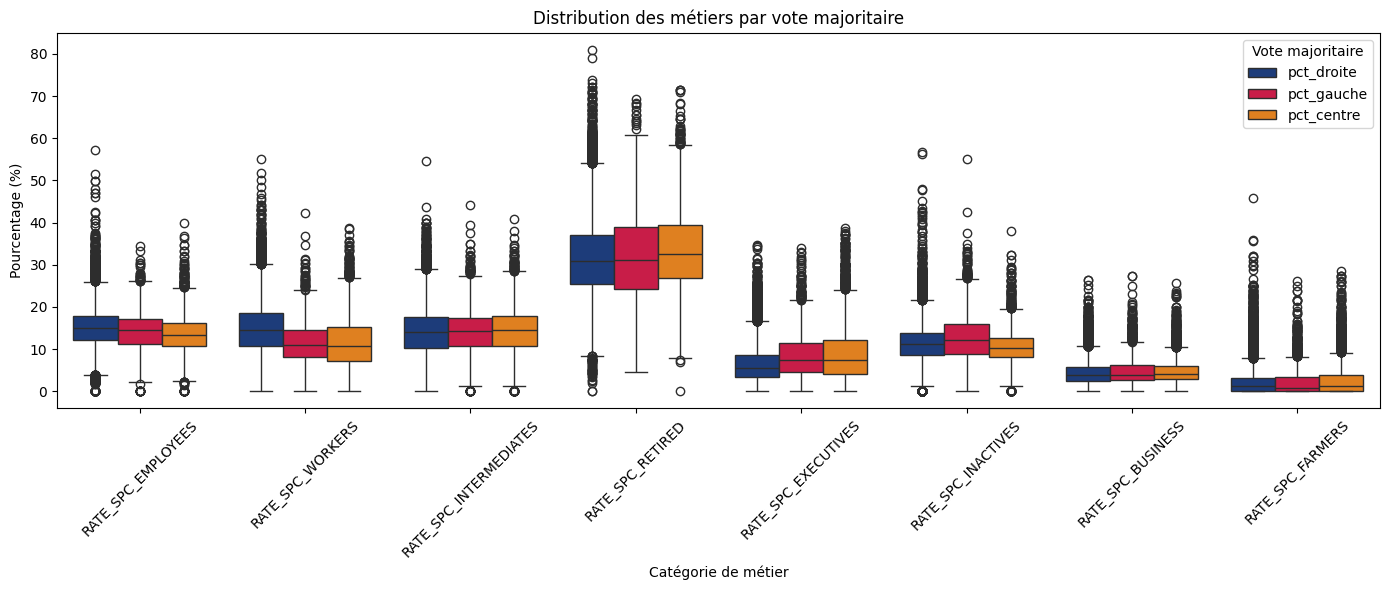

In [87]:
# Transformer le dataframe en format long pour seaborn
df_metier = df[metier + ['majorite']].melt(
    id_vars='majorite',
    value_vars=metier,
    var_name='metier',
    value_name='pourcentage'
)

# Boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_metier,
    x='metier',
    y='pourcentage',
    hue='majorite',
    palette={'pct_gauche': '#E4003A', 'pct_centre': '#FF8000', 'pct_droite': '#0D378A'}
)

plt.title('Distribution des métiers par vote majoritaire')
plt.xlabel('Catégorie de métier')
plt.ylabel('Pourcentage (%)')
plt.xticks(rotation=45)
plt.legend(title='Vote majoritaire')
plt.tight_layout()
plt.show()

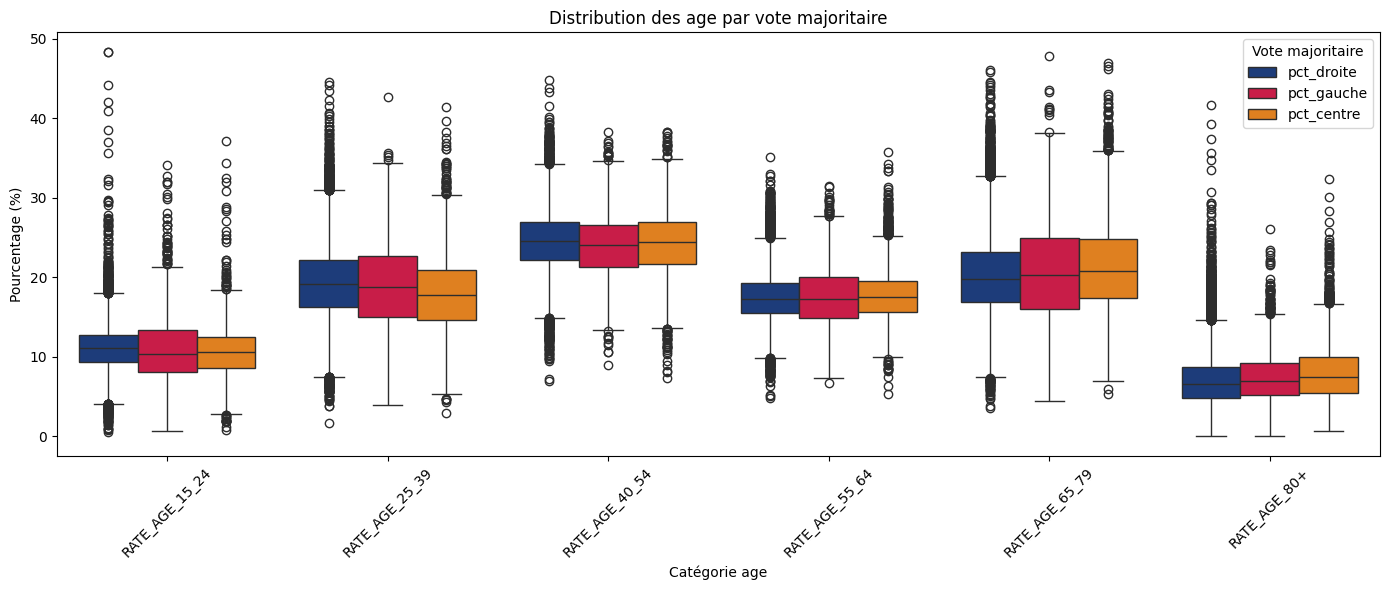

In [88]:
# Transformer le dataframe en format long pour seaborn
df_age = df[age + ['majorite']].melt(
    id_vars='majorite',
    value_vars=age,
    var_name='age',
    value_name='pourcentage'
)

# Boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_age,
    x='age',
    y='pourcentage',
    hue='majorite',
    palette={'pct_gauche': '#E4003A', 'pct_centre': '#FF8000', 'pct_droite': '#0D378A'}
)

plt.title('Distribution des age par vote majoritaire')
plt.xlabel('Catégorie age')
plt.ylabel('Pourcentage (%)')
plt.xticks(rotation=45)
plt.legend(title='Vote majoritaire')
plt.tight_layout()
plt.show()

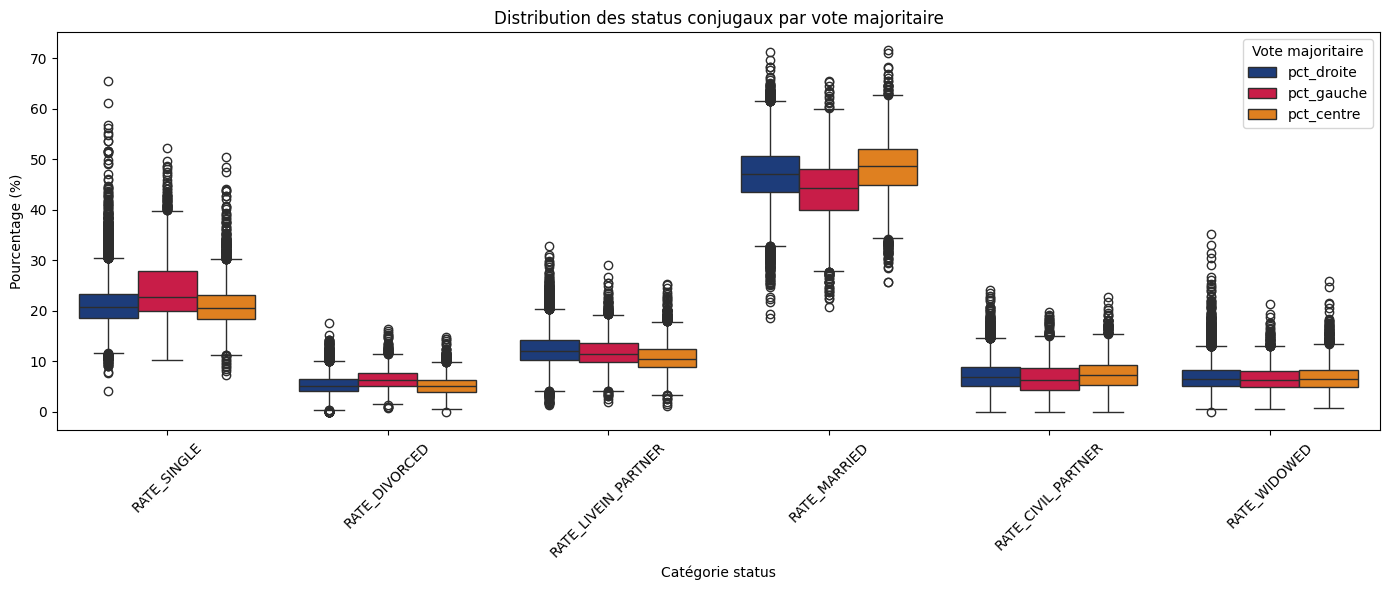

In [89]:
# Transformer le dataframe en format long pour seaborn
df_status = df[status + ['majorite']].melt(
    id_vars='majorite',
    value_vars=status,
    var_name='status',
    value_name='pourcentage'
)

# Boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_status,
    x='status',
    y='pourcentage',
    hue='majorite',
    palette={'pct_gauche': '#E4003A', 'pct_centre': '#FF8000', 'pct_droite': '#0D378A'}
)

plt.title('Distribution des status conjugaux par vote majoritaire')
plt.xlabel('Catégorie status')
plt.ylabel('Pourcentage (%)')
plt.xticks(rotation=45)
plt.legend(title='Vote majoritaire')
plt.tight_layout()
plt.show()

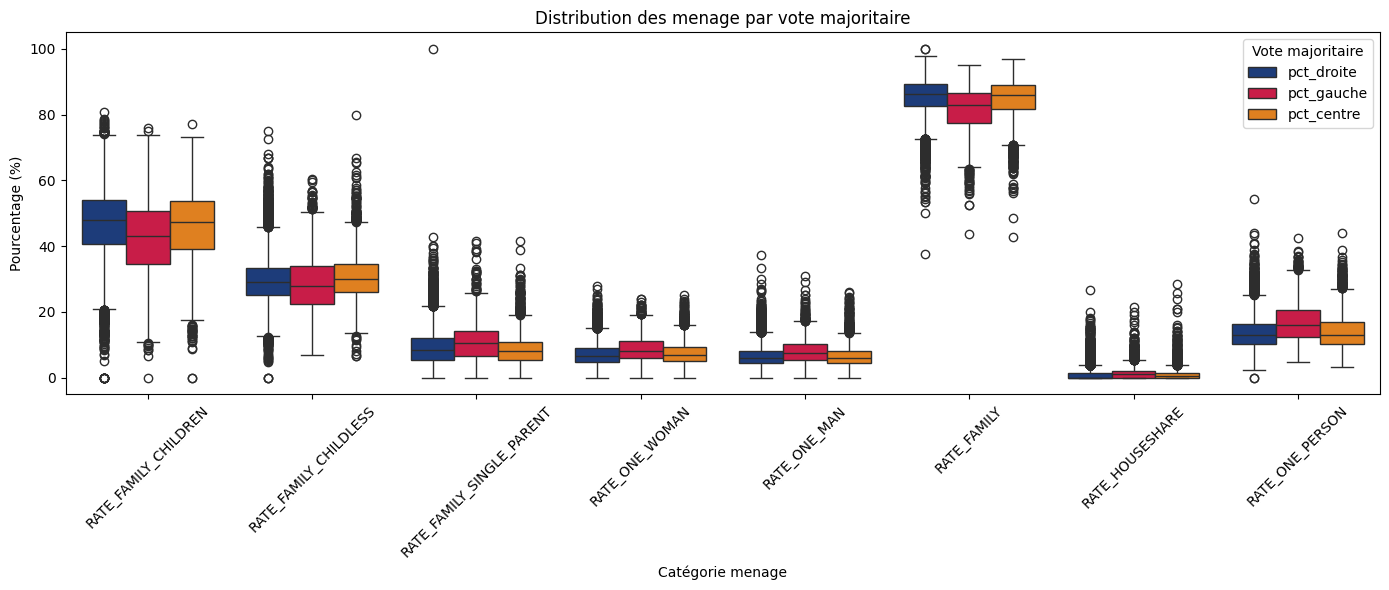

In [90]:
# Transformer le dataframe en format long pour seaborn
df_menage = df[menage + ['majorite']].melt(
    id_vars='majorite',
    value_vars=menage,
    var_name='menage',
    value_name='pourcentage'
)

# Boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_menage,
    x='menage',
    y='pourcentage',
    hue='majorite',
    palette={'pct_gauche': '#E4003A', 'pct_centre': '#FF8000', 'pct_droite': '#0D378A'}
)

plt.title('Distribution des menage par vote majoritaire')
plt.xlabel('Catégorie menage')
plt.ylabel('Pourcentage (%)')
plt.xticks(rotation=45)
plt.legend(title='Vote majoritaire')
plt.tight_layout()
plt.show()

### Corrélation 

In [91]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix[corr_matrix.abs() > 0.5].stack().dropna()

POPULATION_TOTAL   POPULATION_TOTAL     1.000000
                   Inscrits             0.994448
                   Abstentions          0.986824
                   Votants              0.992849
                   Blancs               0.977069
                                          ...   
sum_age            sum_age              1.000000
sum_status         sum_status           1.000000
sum_menage_top     sum_menage_top       1.000000
sum_menage_no_top  RATE_HOUSESHARE     -1.000000
                   sum_menage_no_top    1.000000
Length: 194, dtype: float64

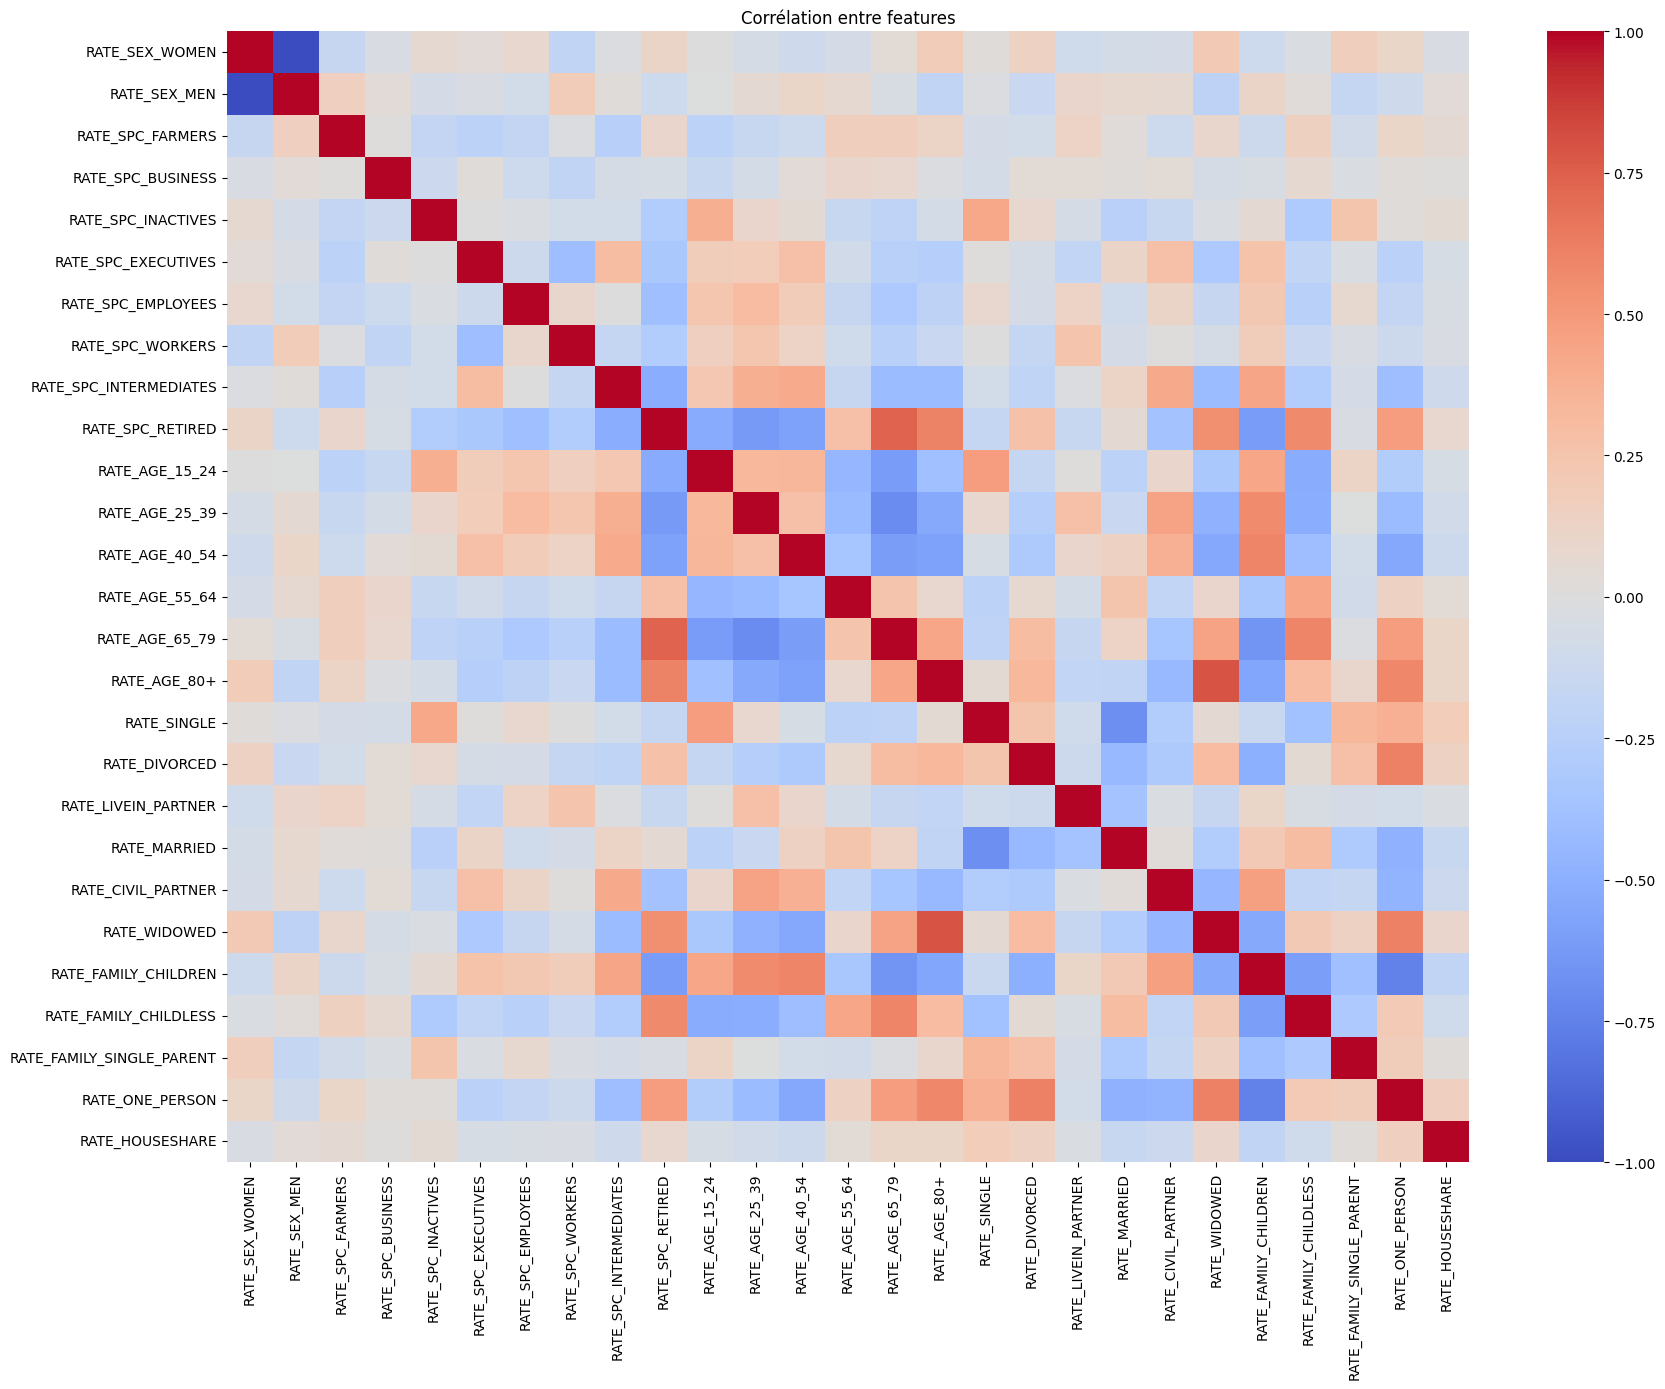

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt

# Colonnes features uniquement (sans colonnes elections et cible)
features = [
    'RATE_SEX_WOMEN', 'RATE_SEX_MEN',
    'RATE_SPC_FARMERS', 'RATE_SPC_BUSINESS', 'RATE_SPC_INACTIVES',
    'RATE_SPC_EXECUTIVES', 'RATE_SPC_EMPLOYEES', 'RATE_SPC_WORKERS',
    'RATE_SPC_INTERMEDIATES', 'RATE_SPC_RETIRED',
    'RATE_AGE_15_24', 'RATE_AGE_25_39', 'RATE_AGE_40_54',
    'RATE_AGE_55_64', 'RATE_AGE_65_79', 'RATE_AGE_80+',
    'RATE_SINGLE', 'RATE_DIVORCED', 'RATE_LIVEIN_PARTNER',
    'RATE_MARRIED', 'RATE_CIVIL_PARTNER', 'RATE_WIDOWED',
    'RATE_FAMILY_CHILDREN', 'RATE_FAMILY_CHILDLESS',
    'RATE_FAMILY_SINGLE_PARENT', 'RATE_ONE_PERSON', 'RATE_HOUSESHARE'
]

corr_matrix = df[features].corr()

plt.figure(figsize=(18, 14))
sns.heatmap(
    corr_matrix,
    annot=False,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1
)

plt.title('Corrélation entre features')
plt.tight_layout()
plt.show()

In [93]:
# Paires de features avec corrélation > 0.8 ou < -0.8
corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs[
    ((corr_pairs > 0.7) | (corr_pairs < -0.7)) & (corr_pairs != 1.0)
].sort_values(ascending=False)

# Supprimer les doublons (A-B et B-A)
corr_pairs = corr_pairs[~corr_pairs.index.duplicated()]

print(corr_pairs)

RATE_WIDOWED          RATE_AGE_80+            0.792608
RATE_AGE_80+          RATE_WIDOWED            0.792608
RATE_AGE_65_79        RATE_SPC_RETIRED        0.736581
RATE_SPC_RETIRED      RATE_AGE_65_79          0.736581
RATE_FAMILY_CHILDREN  RATE_ONE_PERSON        -0.743980
RATE_ONE_PERSON       RATE_FAMILY_CHILDREN   -0.743980
RATE_SEX_WOMEN        RATE_SEX_MEN           -1.000000
RATE_SEX_MEN          RATE_SEX_WOMEN         -1.000000
dtype: float64


In [94]:
# Suppression des colonnes redondantes
colonnes_a_supprimer = [
    'RATE_SEX_MEN',        # redondant parfait avec RATE_SEX_WOMEN
    'RATE_ONE_MAN',        # redondant avec RATE_ONE_PERSON
    'RATE_ONE_WOMAN',      # redondant avec RATE_ONE_PERSON
    'RATE_FAMILY',         # somme des sous-catégories famille
    # Colonnes elections - ne pas utiliser comme features
    'Inscrits', 'Abstentions', 'Votants', 'Blancs', 'Nuls', 'Exprimés',
    'pct_abstention', 'pct_blancs', 'pct_nuls',
    'pct_gauche', 'pct_centre', 'pct_droite',
    # Colonnes de controle
    'sum_metier', 'sum_age', 'sum_status', 'sum_menage_top', 'sum_menage_no_top'
]

df_model = df.drop(columns=colonnes_a_supprimer)

# Vérification
print(f"Colonnes restantes : {df_model.shape[1]}")
print(df_model.columns.tolist())

Colonnes restantes : 30
['CITY', 'CODE_INSEE', 'POPULATION_TOTAL', 'RATE_SEX_WOMEN', 'RATE_SPC_FARMERS', 'RATE_SPC_BUSINESS', 'RATE_SPC_INACTIVES', 'RATE_SPC_EXECUTIVES', 'RATE_SPC_EMPLOYEES', 'RATE_SPC_WORKERS', 'RATE_SPC_INTERMEDIATES', 'RATE_SPC_RETIRED', 'RATE_FAMILY_CHILDREN', 'RATE_FAMILY_CHILDLESS', 'RATE_FAMILY_SINGLE_PARENT', 'RATE_HOUSESHARE', 'RATE_ONE_PERSON', 'RATE_AGE_80+', 'RATE_AGE_15_24', 'RATE_AGE_25_39', 'RATE_AGE_40_54', 'RATE_AGE_55_64', 'RATE_AGE_65_79', 'RATE_SINGLE', 'RATE_DIVORCED', 'RATE_LIVEIN_PARTNER', 'RATE_MARRIED', 'RATE_CIVIL_PARTNER', 'RATE_WIDOWED', 'majorite']


In [96]:
print(df_model['majorite'].value_counts())

majorite
pct_droite    19669
pct_centre     3833
pct_gauche     2287
Name: count, dtype: int64


In [97]:
def categorie_commune(habitants):
    if habitants < 2000:
        return "rurale"
    elif habitants < 10000:
        return "petite_commune"
    elif habitants < 50000:
        return "ville_moyenne"
    elif habitants < 100000:
        return "grande_ville"
    else:
        return "tres_grande_ville"

df_model['categorie_commune'] = df_model['POPULATION_TOTAL'].apply(categorie_commune)

# Vérification
print(df_model['categorie_commune'].value_counts())

categorie_commune
rurale               21463
petite_commune        3567
ville_moyenne          671
grande_ville            58
tres_grande_ville       30
Name: count, dtype: int64


In [98]:
df_model = pd.get_dummies(df_model, columns=['categorie_commune'], prefix='commune')

# Vérification
print(df_model.columns.tolist())

['CITY', 'CODE_INSEE', 'POPULATION_TOTAL', 'RATE_SEX_WOMEN', 'RATE_SPC_FARMERS', 'RATE_SPC_BUSINESS', 'RATE_SPC_INACTIVES', 'RATE_SPC_EXECUTIVES', 'RATE_SPC_EMPLOYEES', 'RATE_SPC_WORKERS', 'RATE_SPC_INTERMEDIATES', 'RATE_SPC_RETIRED', 'RATE_FAMILY_CHILDREN', 'RATE_FAMILY_CHILDLESS', 'RATE_FAMILY_SINGLE_PARENT', 'RATE_HOUSESHARE', 'RATE_ONE_PERSON', 'RATE_AGE_80+', 'RATE_AGE_15_24', 'RATE_AGE_25_39', 'RATE_AGE_40_54', 'RATE_AGE_55_64', 'RATE_AGE_65_79', 'RATE_SINGLE', 'RATE_DIVORCED', 'RATE_LIVEIN_PARTNER', 'RATE_MARRIED', 'RATE_CIVIL_PARTNER', 'RATE_WIDOWED', 'majorite', 'commune_grande_ville', 'commune_petite_commune', 'commune_rurale', 'commune_tres_grande_ville', 'commune_ville_moyenne']


              precision    recall  f1-score   support

  pct_centre       0.54      0.28      0.37       767
  pct_droite       0.82      0.94      0.88      3934
  pct_gauche       0.52      0.30      0.38       457

    accuracy                           0.78      5158
   macro avg       0.62      0.51      0.54      5158
weighted avg       0.75      0.78      0.76      5158



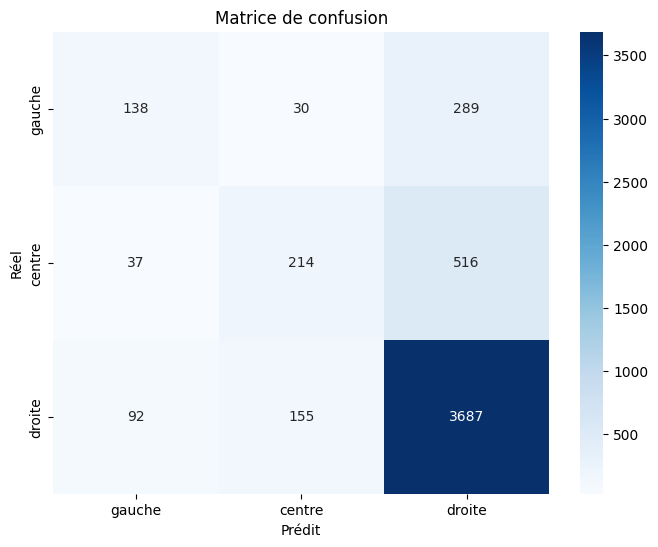

In [101]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Features et cible
features = [col for col in df_model.columns if col not in ['CITY', 'CODE_INSEE', 'POPULATION_TOTAL', 'majorite']]
X = df_model[features]
y = df_model['majorite']

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Modèle
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    class_weight={
    'pct_droite': 1,
    'pct_centre': 5,
    'pct_gauche': 10},  # compense le déséquilibre des classes
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Evaluation
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred, labels=['pct_gauche', 'pct_centre', 'pct_droite'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=['gauche', 'centre', 'droite'],
            yticklabels=['gauche', 'centre', 'droite'],
            cmap='Blues')
plt.title('Matrice de confusion')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.show()